In [3]:
# Install required packages
#%pip install tqdm
#%pip install scipy
#%pip install scikit-learn
#%pip install pyyaml
#%pip install seaborn
#%pip install dask
#%pip install netcdf4
#%pip install h5py
#%pip install xarray

  Using cached xarray-2026.4.0-py3-none-any.whl.metadata (12 kB)
Using cached xarray-2026.4.0-py3-none-any.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import required packages
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import glob
import os
from pathlib import Path

# Reusable framework code (installed via `pip install -e .` from the repo root)
from sdframework import config as sdconfig
from sdframework.io import load_basin_data, load_nc_data

In [ ]:
# Configuration (paths resolved by sdframework.config; keeps the original
# `config[...]` keys so the rest of the notebook is unchanged).
# NOTE: this also fixes the original 'DATA' vs 'Data' casing inconsistency for
# the precipitation input, which broke on case-sensitive filesystems.
config = {
    'casr_SWE_input_dir': sdconfig.input_data('CaSR_SWE', 'combined_SWE_new.nc'),
    'casr_P_input_dir': sdconfig.input_data('CaSR_precipitation', 'combined_precipitation.nc'),
    'shapefile': sdconfig.elevation_shapefile(),
    'output_dir_precip': sdconfig.output_data('CaSR', 'precipitation'),
    'Output_dir_SWE': sdconfig.output_data('CaSR', 'SWE'),
    'output_dir': sdconfig.output_data('CaSR'),
    'output_plots': sdconfig.output_plots('CaSR'),
}

In [4]:
# 1. Load Shapefile ===
gdf_Alberta = load_basin_data(config['shapefile'])
display(gdf_Alberta.head())

,HUC_6,HUC_4,HUC_2,WSC_CODE,NAME,SHAPE_STAr,SHAPE_STLe,min,max,mean,count,std,median,elev_class,geometry
0,150101,1501,15,06BA,CHURCHILL RIVER,2.429876e+08,122121.046343,466.0,529.0,480.871911,485200,12.185533,479.0,0_500m,"MULTIPOLYGON (((-110.0058 56.48389, -110.0058 ..."
1,170602,1706,17,07CD,CLEARWATER RIVER,3.767044e+09,552637.416284,239.0,772.0,482.667477,7597072,94.635664,481.0,0_500m,"POLYGON ((-110.00588 57.14721, -110.00588 57.1..."
2,180302,1803,18,07HD,SCULLY CREEK - PEACE RIVER ABOVE KEG RIVER,1.763267e+09,264515.152839,236.0,732.0,422.857475,3643005,93.153718,423.0,0_500m,"POLYGON ((-116.99116 57.86992, -116.99163 57.8..."
3,170701,1707,17,07DA,ELLS - STEEPBANK RIVERS,8.860736e+09,741678.487606,217.0,863.0,482.431090,18172482,174.258607,456.0,0_500m,"POLYGON ((-112.02942 57.837, -112.02909 57.836..."
4,170703,1707,17,07DC,FIREBAG RIVER,5.761016e+09,472230.507427,222.0,669.0,431.334314,11866214,104.775221,438.0,0_500m,"POLYGON ((-110.56 57.85874, -110.55981 57.8585..."


# Precipitation

In [80]:
#2. Load Precipitation Data ===
precip_path = Path(config["casr_P_input_dir"])

precip_ds = load_nc_data(precip_path)

display(precip_ds)

<xarray.Dataset> Size: 29GB
Dimensions:               (time: 394488, rlat: 175, rlon: 105)
Coordinates:
  * time                  (time) datetime64[ns] 3MB 1979-12-31T13:00:00 ... 2...
  * rlat                  (rlat) float64 1kB -9.45 -9.36 -9.27 ... 6.12 6.21
  * rlon                  (rlon) float64 840B -16.5 -16.41 ... -7.227 -7.137
    lon                   (rlat, rlon) float32 74kB ...
    lat                   (rlat, rlon) float32 74kB ...
Data variables:
    rotated_pole          int32 4B ...
    CaSR_v3.2_A_PR24_SFC  (time, rlat, rlon) float32 29GB ...
Attributes:
    Conventions:  CF-1.6
    source:       https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/
    institution:  Environment and Climate Change Canada / Environnement et Ch...
    title:        Canadian Surface Reanalysis (CaSR) / Réanalyse Canadienne d...
    contact:      rcas-casr@ec.gc.ca
    licence:      These data are produced and provided by the Environment and...

In [60]:
print(precip_ds)
print(precip_ds.time[:10].values)
print(precip_ds.time[-10:].values)

<xarray.Dataset> Size: 29GB
Dimensions:               (time: 389352, rlat: 175, rlon: 105)
Coordinates:
  * time                  (time) datetime64[ns] 3MB 1980-01-01 ... 2024-05-31...
  * rlat                  (rlat) float64 1kB -9.45 -9.36 -9.27 ... 6.12 6.21
  * rlon                  (rlon) float64 840B -16.5 -16.41 ... -7.227 -7.137
    lon                   (rlat, rlon) float32 74kB ...
    lat                   (rlat, rlon) float32 74kB ...
Data variables:
    rotated_pole          int32 4B ...
    CaSR_v3.2_A_PR24_SFC  (time, rlat, rlon) float32 29GB ...
Attributes:
    Conventions:  CF-1.6
    source:       https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/
    institution:  Environment and Climate Change Canada / Environnement et Ch...
    title:        Canadian Surface Reanalysis (CaSR) / Réanalyse Canadienne d...
    contact:      rcas-casr@ec.gc.ca
    licence:      These data are produced and provided by the Environment and...
['1980-01-01T00:00:00.000000000' '1980-01-0

In [63]:
pr = precip_ds["CaSR_v3.2_A_PR24_SFC"]

pr = pr.sel(time=slice("1980-01-01", "2024-05-31"))

# hourly/sub-daily → daily precipitation total
pr_daily = pr.resample(time="1D").sum()

print(pr_daily.shape)

(16223, 175, 105)


In [65]:
for year in range(1980, 2025):
    df_year = (
        pr_daily.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
        .to_dataframe(name="precip")
        .reset_index()
    )

    df_year.to_csv(config["output_dir_precip"] + f"precip_daily_grid_{year}.csv", index=False)
    print("saved", year, df_year.shape)

saved 1980 (6725250, 6)
saved 1981 (6706875, 6)
saved 1982 (6706875, 6)
saved 1983 (6706875, 6)
saved 1984 (6725250, 6)
saved 1985 (6706875, 6)
saved 1986 (6706875, 6)
saved 1987 (6706875, 6)
saved 1988 (6725250, 6)
saved 1989 (6706875, 6)
saved 1990 (6706875, 6)
saved 1991 (6706875, 6)
saved 1992 (6725250, 6)
saved 1993 (6706875, 6)
saved 1994 (6706875, 6)
saved 1995 (6706875, 6)
saved 1996 (6725250, 6)
saved 1997 (6706875, 6)
saved 1998 (6706875, 6)
saved 1999 (6706875, 6)
saved 2000 (6725250, 6)
saved 2001 (6706875, 6)
saved 2002 (6706875, 6)
saved 2003 (6706875, 6)
saved 2004 (6725250, 6)
saved 2005 (6706875, 6)
saved 2006 (6706875, 6)
saved 2007 (6706875, 6)
saved 2008 (6725250, 6)
saved 2009 (6706875, 6)
saved 2010 (6706875, 6)
saved 2011 (6706875, 6)
saved 2012 (6725250, 6)
saved 2013 (6706875, 6)
saved 2014 (6706875, 6)
saved 2015 (6706875, 6)
saved 2016 (6725250, 6)
saved 2017 (6706875, 6)
saved 2018 (6706875, 6)
saved 2019 (6706875, 6)
saved 2020 (6725250, 6)
saved 2021 (6706

In [123]:
# open precip_daily_grid_1980.csv
df_1980 = pd.read_csv(config["output_dir_precip"] / "precip_daily_grid_1980.csv")

#convert lon from 0-360 to -180 to 180 format
df_1980['lon'] = ((df_1980['lon'] + 180) % 360) - 180

# drop rows with missing values
df_1980 = df_1980.dropna(subset=['precip', 'lat', 'lon'])



# convert to GeoDataFrame
gdf_Alberta_precip_data = gpd.GeoDataFrame(
    df_1980,
    geometry=gpd.points_from_xy(df_1980['lon'], df_1980['lat']),
    crs='EPSG:4326'  # Assuming the coordinates are in WGS84
)

# Display the GeoDataFrames
display(gdf_Alberta_precip_data.head())

,time,rlat,rlon,lon,lat,precip,geometry
0,1980-01-01,-9.450001,-16.497223,-116.12598,45.872430,0.001511,POINT (-116.12598 45.87243)
1,1980-01-01,-9.450001,-16.407211,-116.00629,45.903150,0.001455,POINT (-116.00629 45.90315)
2,1980-01-01,-9.450001,-16.317215,-115.88647,45.933716,0.001442,POINT (-115.88647 45.93372)
3,1980-01-01,-9.450001,-16.227219,-115.76651,45.964134,0.001459,POINT (-115.76651 45.96413)
4,1980-01-01,-9.450001,-16.137222,-115.64642,45.994408,0.001666,POINT (-115.64642 45.99441)


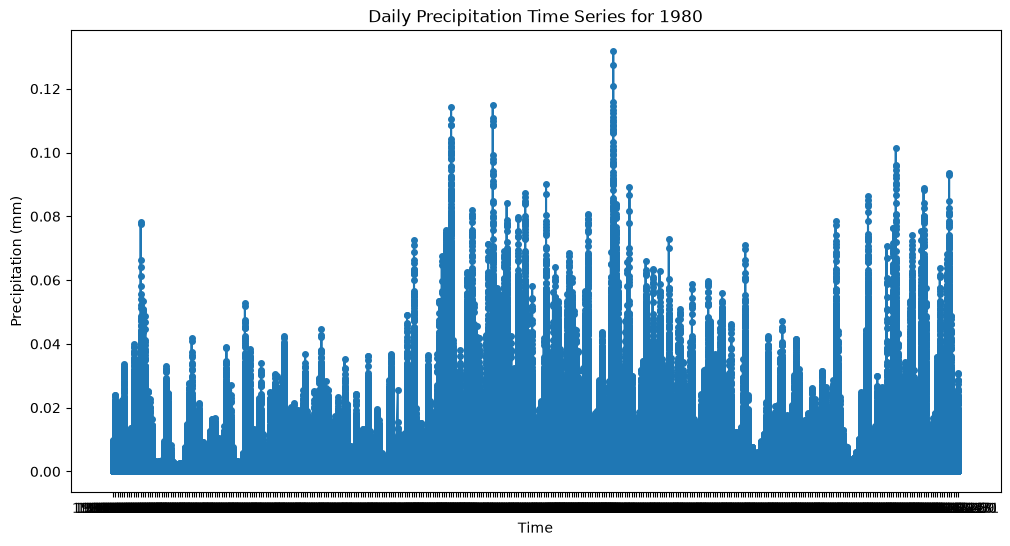

In [104]:
# plot time series of precip for df_1980
plt.figure(figsize=(12, 6))
plt.plot(df_1980['time'], df_1980['precip'], marker='o', linestyle='-', markersize=4)
plt.title('Daily Precipitation Time Series for 1980')
plt.xlabel('Time')
plt.ylabel('Precipitation (mm)')
plt.show()

In [72]:
# ensure shapefile and points use same CRS
if gdf_Alberta.crs is None:
    gdf_Alberta = gdf_Alberta.set_crs("EPSG:4326")

if gdf_Alberta.crs != gdf_Alberta_precip_data.crs:
    gdf_Alberta = gdf_Alberta.to_crs(gdf_Alberta_precip_data.crs)

# spatial join: keep only points inside any polygon in gdf_Alberta
try:
    gdf_precip_in_alberta = gpd.sjoin(
        gdf_Alberta_precip_data, gdf_Alberta[["geometry"]],
        how="inner", predicate="within"
    ).drop(columns="index_right")
except TypeError:
    # fallback for older geopandas using 'op'
    gdf_precip_in_alberta = gpd.sjoin(
        gdf_Alberta_precip_data, gdf_Alberta[["geometry"]],
        how="inner", op="within"
    ).drop(columns="index_right")

print("points inside shapefile:", gdf_precip_in_alberta.shape)
display(gdf_precip_in_alberta.head())

points inside shapefile: (2417430, 7)


,time,rlat,rlon,lon,lat,precip,geometry
2152,1980-01-01,-7.65,-11.817215,-110.42682,49.006240,0.000003,POINT (-110.42682 49.00624)
2153,1980-01-01,-7.65,-11.727219,-110.29562,49.029830,0.000003,POINT (-110.29562 49.02983)
2154,1980-01-01,-7.65,-11.637222,-110.16434,49.053257,0.000001,POINT (-110.16434 49.05326)
2155,1980-01-01,-7.65,-11.547226,-110.03293,49.076515,0.000000,POINT (-110.03293 49.07652)
2254,1980-01-01,-7.56,-12.087219,-110.85672,49.021076,0.000000,POINT (-110.85672 49.02108)


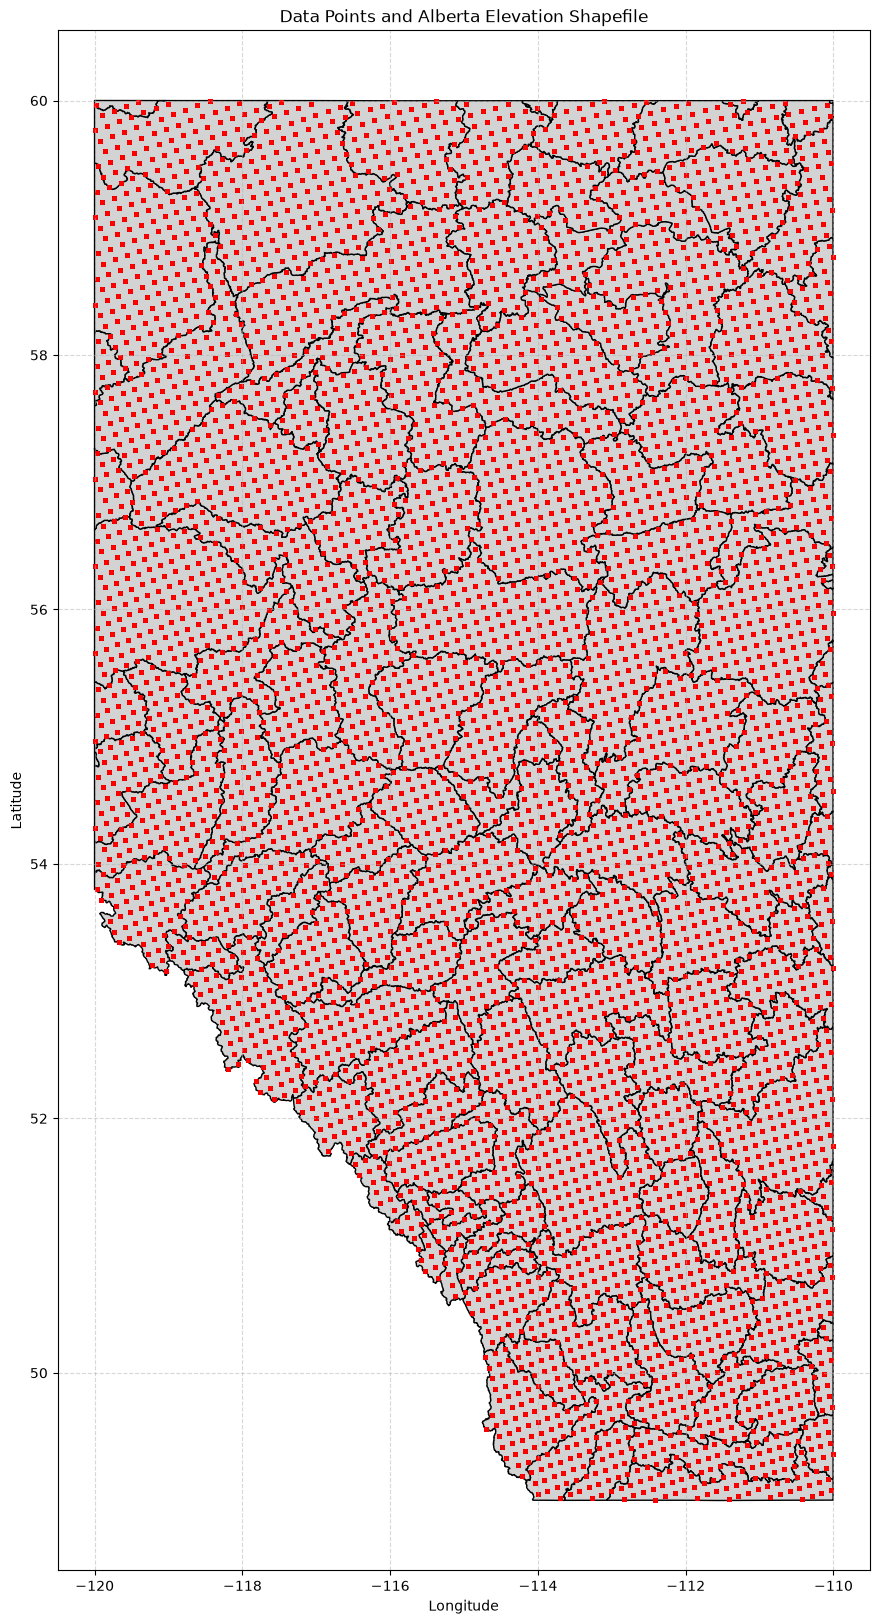

In [77]:
# plot data points and shapefile
fig, ax = plt.subplots(figsize=(20, 20))
gdf_Alberta.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf_precip_in_alberta.plot(ax=ax, color='red', markersize=5, label='Points in Shapefile')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Data Points and Alberta Elevation Shapefile')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

# SWE

In [118]:
#2. Load SWE Data ===
swe_path = Path(config["casr_SWE_input_dir"])

swe_ds = load_nc_data(swe_path)

display(swe_ds)

<xarray.Dataset> Size: 29GB
Dimensions:               (time: 394488, rlat: 175, rlon: 105)
Coordinates:
  * time                  (time) datetime64[ns] 3MB 1979-12-31T13:00:00 ... 2...
  * rlat                  (rlat) float64 1kB -9.45 -9.36 -9.27 ... 6.12 6.21
  * rlon                  (rlon) float64 840B -16.5 -16.41 ... -7.227 -7.137
    lon                   (rlat, rlon) float32 74kB ...
    lat                   (rlat, rlon) float32 74kB ...
Data variables:
    rotated_pole          int32 4B ...
    CaSR_v3.2_P_SWE_LAND  (time, rlat, rlon) float32 29GB ...
Attributes:
    Conventions:  CF-1.6
    source:       https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/
    institution:  Environment and Climate Change Canada / Environnement et Ch...
    title:        Canadian Surface Reanalysis (CaSR) / Réanalyse Canadienne d...
    contact:      rcas-casr@ec.gc.ca
    licence:      These data are produced and provided by the Environment and...

In [119]:
print(swe_ds)
print(swe_ds.time[:10].values)
print(swe_ds.time[-10:].values)

<xarray.Dataset> Size: 29GB
Dimensions:               (time: 394488, rlat: 175, rlon: 105)
Coordinates:
  * time                  (time) datetime64[ns] 3MB 1979-12-31T13:00:00 ... 2...
  * rlat                  (rlat) float64 1kB -9.45 -9.36 -9.27 ... 6.12 6.21
  * rlon                  (rlon) float64 840B -16.5 -16.41 ... -7.227 -7.137
    lon                   (rlat, rlon) float32 74kB ...
    lat                   (rlat, rlon) float32 74kB ...
Data variables:
    rotated_pole          int32 4B ...
    CaSR_v3.2_P_SWE_LAND  (time, rlat, rlon) float32 29GB ...
Attributes:
    Conventions:  CF-1.6
    source:       https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/
    institution:  Environment and Climate Change Canada / Environnement et Ch...
    title:        Canadian Surface Reanalysis (CaSR) / Réanalyse Canadienne d...
    contact:      rcas-casr@ec.gc.ca
    licence:      These data are produced and provided by the Environment and...
['1979-12-31T13:00:00.000000000' '1979-12-3

In [120]:
swe = swe_ds["CaSR_v3.2_P_SWE_LAND"]

swe_daily = swe.sel(time=swe.time.dt.hour == 12)

print(swe_daily)

<xarray.DataArray 'CaSR_v3.2_P_SWE_LAND' (time: 16437, rlat: 175, rlon: 105)> Size: 1GB
[302029875 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 131kB 1980-01-01T12:00:00 ... 2024-12-31T1...
  * rlat     (rlat) float64 1kB -9.45 -9.36 -9.27 -9.18 ... 5.94 6.03 6.12 6.21
  * rlon     (rlon) float64 840B -16.5 -16.41 -16.32 ... -7.317 -7.227 -7.137
    lon      (rlat, rlon) float32 74kB ...
    lat      (rlat, rlon) float32 74kB ...
Attributes:
    standard_name:  Water equivalent of snow cover
    long_name:      Forecast: Water equivalent of snow cover at land surface ...
    units:          kg m**-2
    grid_mapping:   rotated_pole


In [121]:
for year in range(1980, 2025):
    df_year = (
        swe_daily.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
        .to_dataframe(name="swe")
        .reset_index()
    )

    config["Output_dir_SWE"].mkdir(parents=True, exist_ok=True)
    df_year.to_csv(config["Output_dir_SWE"] / f"swe_daily_grid_{year}.csv", index=False)
    print("saved", year, df_year.shape)

saved 1980 (6725250, 6)
saved 1981 (6706875, 6)
saved 1982 (6706875, 6)
saved 1983 (6706875, 6)
saved 1984 (6725250, 6)
saved 1985 (6706875, 6)
saved 1986 (6706875, 6)
saved 1987 (6706875, 6)
saved 1988 (6725250, 6)
saved 1989 (6706875, 6)
saved 1990 (6706875, 6)
saved 1991 (6706875, 6)
saved 1992 (6725250, 6)
saved 1993 (6706875, 6)
saved 1994 (6706875, 6)
saved 1995 (6706875, 6)
saved 1996 (6725250, 6)
saved 1997 (6706875, 6)
saved 1998 (6706875, 6)
saved 1999 (6706875, 6)
saved 2000 (6725250, 6)
saved 2001 (6706875, 6)
saved 2002 (6706875, 6)
saved 2003 (6706875, 6)
saved 2004 (6725250, 6)
saved 2005 (6706875, 6)
saved 2006 (6706875, 6)
saved 2007 (6706875, 6)
saved 2008 (6725250, 6)
saved 2009 (6706875, 6)
saved 2010 (6706875, 6)
saved 2011 (6706875, 6)
saved 2012 (6725250, 6)
saved 2013 (6706875, 6)
saved 2014 (6706875, 6)
saved 2015 (6706875, 6)
saved 2016 (6725250, 6)
saved 2017 (6706875, 6)
saved 2018 (6706875, 6)
saved 2019 (6706875, 6)
saved 2020 (6725250, 6)
saved 2021 (6706

In [124]:
# open swe_daily_grid_1996.csv
df_1996 = pd.read_csv(config["Output_dir_SWE"] / "swe_daily_grid_1996.csv")

#convert lon from 0-360 to -180 to 180 format
df_1996['lon'] = ((df_1996['lon'] + 180) % 360) - 180

# drop rows with missing values
df_1996 = df_1996.dropna(subset=['swe', 'lat', 'lon'])



# convert to GeoDataFrame
gdf_Alberta_swe_data = gpd.GeoDataFrame(
    df_1996,
    geometry=gpd.points_from_xy(df_1996['lon'], df_1996['lat']),
    crs='EPSG:4326'  # Assuming the coordinates are in WGS84
)

# Display the GeoDataFrames
display(gdf_Alberta_swe_data.head())

,time,rlat,rlon,lon,lat,swe,geometry
0,1996-01-01 12:00:00,-9.450001,-16.497223,-116.12598,45.872430,0.125854,POINT (-116.12598 45.87243)
1,1996-01-01 12:00:00,-9.450001,-16.407211,-116.00629,45.903150,0.251526,POINT (-116.00629 45.90315)
2,1996-01-01 12:00:00,-9.450001,-16.317215,-115.88647,45.933716,1.257751,POINT (-115.88647 45.93372)
3,1996-01-01 12:00:00,-9.450001,-16.227219,-115.76651,45.964134,4.758911,POINT (-115.76651 45.96413)
4,1996-01-01 12:00:00,-9.450001,-16.137222,-115.64642,45.994408,10.125000,POINT (-115.64642 45.99441)


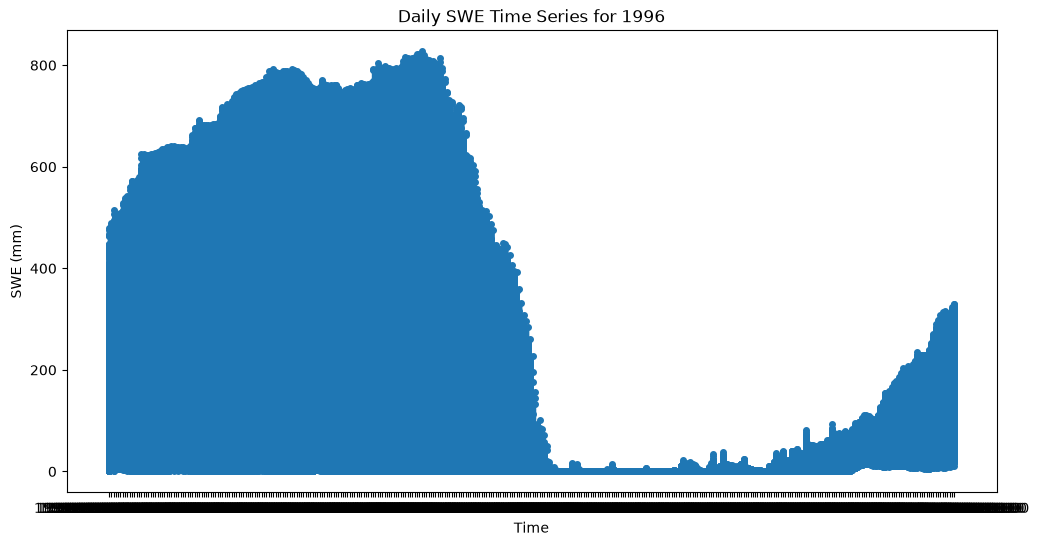

In [114]:
# plot time series of precip for df_1980
plt.figure(figsize=(12, 6))
plt.plot(df_1996['time'], df_1996['swe'], marker='o', linestyle='-', markersize=4)
plt.title('Daily SWE Time Series for 1996')
plt.xlabel('Time')
plt.ylabel('SWE (mm)')
plt.show()

In [125]:
# ensure shapefile and points use same CRS
if gdf_Alberta.crs is None:
    gdf_Alberta = gdf_Alberta.set_crs("EPSG:4326")

if gdf_Alberta.crs != gdf_Alberta_swe_data.crs:
    gdf_Alberta = gdf_Alberta.to_crs(gdf_Alberta_swe_data.crs)

# spatial join: keep only points inside any polygon in gdf_Alberta
try:
    gdf_swe_in_alberta = gpd.sjoin(
        gdf_Alberta_swe_data, gdf_Alberta[["geometry"]],
        how="inner", predicate="within"
    ).drop(columns="index_right")
except TypeError:
    # fallback for older geopandas using 'op'
    gdf_swe_in_alberta = gpd.sjoin(
        gdf_Alberta_swe_data, gdf_Alberta[["geometry"]],
        how="inner", op="within"
    ).drop(columns="index_right")

print("points inside shapefile:", gdf_swe_in_alberta.shape)
display(gdf_swe_in_alberta.head())

points inside shapefile: (2412672, 7)


,time,rlat,rlon,lon,lat,swe,geometry
2152,1996-01-01 12:00:00,-7.65,-11.817215,-110.42682,49.006240,4.250,POINT (-110.42682 49.00624)
2153,1996-01-01 12:00:00,-7.65,-11.727219,-110.29562,49.029830,8.375,POINT (-110.29562 49.02983)
2154,1996-01-01 12:00:00,-7.65,-11.637222,-110.16434,49.053257,12.125,POINT (-110.16434 49.05326)
2155,1996-01-01 12:00:00,-7.65,-11.547226,-110.03293,49.076515,13.750,POINT (-110.03293 49.07652)
2254,1996-01-01 12:00:00,-7.56,-12.087219,-110.85672,49.021076,8.750,POINT (-110.85672 49.02108)


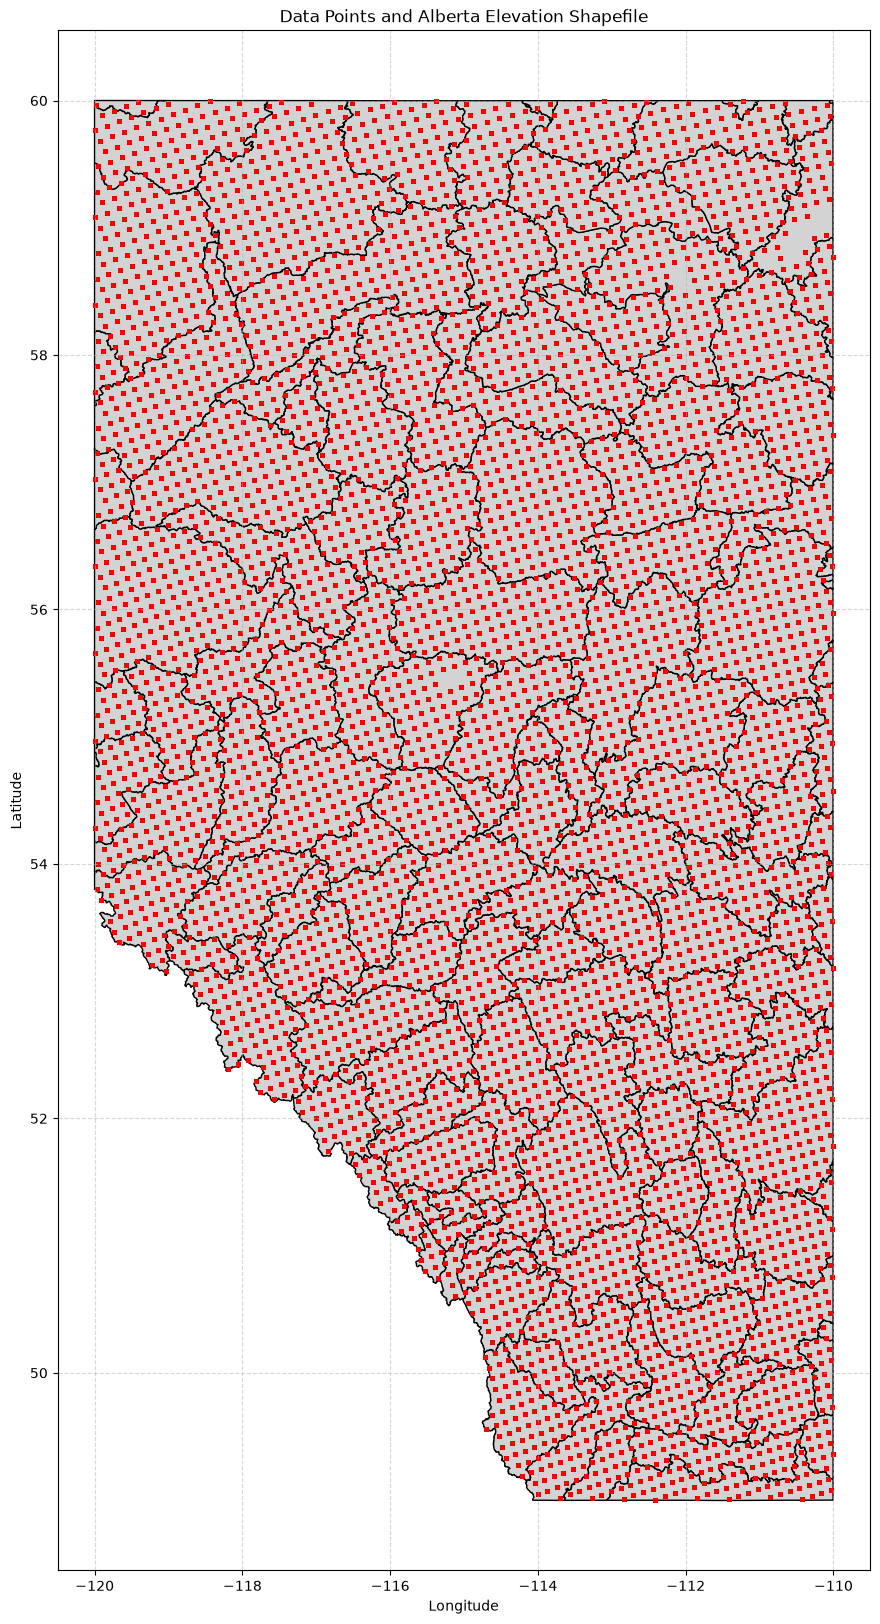

In [126]:
# plot data points and shapefile
fig, ax = plt.subplots(figsize=(20, 20))
gdf_Alberta.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf_swe_in_alberta.plot(ax=ax, color='red', markersize=5, label='Points in Shapefile')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Data Points and Alberta Elevation Shapefile')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

# combine all csv files

In [127]:
# combine precip data into one file
all_precip_files = sorted(config["output_dir_precip"].glob("precip_daily_grid_*.csv"))
all_precip_dfs = []
for file in all_precip_files:
    df = pd.read_csv(file)
    all_precip_dfs.append(df)
combined_precip_df = pd.concat(all_precip_dfs, ignore_index=True)
combined_precip_df.to_csv(config["output_dir_precip"] / "combined_precipitation.csv", index=False)
print("Combined precipitation data saved:", combined_precip_df.shape)   

Combined precipitation data saved: (298097625, 6)


In [133]:
# combine swe data into one file
all_swe_files = sorted(config["Output_dir_SWE"].glob("swe_daily_grid_*.csv"))
all_swe_dfs = []
for file in all_swe_files:
    df = pd.read_csv(file)
    all_swe_dfs.append(df)
combined_swe_df = pd.concat(all_swe_dfs, ignore_index=True)
output_dir_swe = config["Output_dir_SWE"]
output_dir_swe.mkdir(parents=True, exist_ok=True)
combined_swe_df.to_csv(output_dir_swe / "combined_swe.csv", index=False)
print("Combined SWE data saved:", combined_swe_df.shape)

Combined SWE data saved: (302029875, 6)


# Add elevation

In [5]:
precip_files = sorted(config["output_dir_precip"].glob("precip_daily_grid_*.csv"))
swe_files = sorted(config["Output_dir_SWE"].glob("swe_daily_grid_*.csv"))

In [6]:
first_precip = pd.read_csv(precip_files[0])

first_precip["lon"] = ((first_precip["lon"] + 180) % 360) - 180
first_precip["lon"] = first_precip["lon"].round(4)
first_precip["lat"] = first_precip["lat"].round(4)

grid_lookup = (
    first_precip[["lat", "lon"]]
    .drop_duplicates()
    .sort_values(["lat", "lon"])
    .reset_index(drop=True)
)

grid_lookup["Grid_ID"] = range(1, len(grid_lookup) + 1)

In [7]:
# elevation polygons
elev_gdf = gdf_Alberta.copy()

# use first year's file to build lookup
df = pd.read_csv(precip_files[0])

grid_lookup = grid_lookup[["Grid_ID", "lat", "lon"]].drop_duplicates()

grid_points = gpd.GeoDataFrame(
    grid_lookup,
    geometry=gpd.points_from_xy(
        grid_lookup["lon"],
        grid_lookup["lat"]
    ),
    crs="EPSG:4326"
)

grid_elev = gpd.sjoin(
    grid_points,
    elev_gdf[["elev_class", "geometry"]],
    how="left",
    predicate="within"
)

grid_elev_lookup = (
    grid_elev[["Grid_ID", "elev_class", "geometry"]]
    .drop_duplicates()
)

# drop rows with missing elevation class
grid_elev_lookup = grid_elev_lookup.dropna(subset=["elev_class"])

grid_elev_lookup

,Grid_ID,elev_class,geometry
1822,1823,1000_1500m,POINT (-112.4088 49.0028)
1824,1825,1000_1500m,POINT (-110.4268 49.0062)
1825,1826,1000_1500m,POINT (-111.4176 49.0093)
1827,1828,1000_1500m,POINT (-112.8394 49.0095)
1831,1832,1000_1500m,POINT (-113.2702 49.0143)
...,...,...,...
13308,13309,0_500m,POINT (-117.4768 59.9926)
13311,13312,500_1000m,POINT (-118.4438 59.9949)
13312,13313,500_1000m,POINT (-115.3745 59.9976)
13313,13314,0_500m,POINT (-113.1015 59.9977)


In [11]:
# Merge SWE and preciptation data for each year and save to CSV

for p_file in precip_files:
    year = p_file.stem.split("_")[-1]

    s_file = config["Output_dir_SWE"] / f"swe_daily_grid_{year}.csv"

    if not s_file.exists():
        print(f"Skipping {year}: SWE file not found")
        continue

    print(f"Processing {year}")

    precip = pd.read_csv(p_file)
    swe = pd.read_csv(s_file)

    precip["precip"] = precip["precip"] * 1000

    for df in [precip, swe]:
        df["time"] = pd.to_datetime(df["time"]).dt.normalize()
        df["lon"] = ((df["lon"] + 180) % 360) - 180
        df["lon"] = df["lon"].round(4)
        df["lat"] = df["lat"].round(4)

        for c in ["geometry", "rlat", "rlon", "rotated_pole"]:
            if c in df.columns:
                df.drop(columns=c, inplace=True)

    key_cols = ["time", "lon", "lat"]

    precip = precip.drop_duplicates(subset=key_cols)
    swe = swe.drop_duplicates(subset=key_cols)

    # merge precip + SWE
    merged = precip.merge(
        swe[[*key_cols, *[c for c in swe.columns if c not in key_cols]]],
        on=key_cols,
        how="inner",
        validate="one_to_one"
    )

    # add Grid_ID
    merged = merged.merge(grid_lookup, on=["lat", "lon"], how="left")

    # add elev_class
    merged = merged.merge(
        grid_elev_lookup[["Grid_ID", "elev_class"]],
        on="Grid_ID",
        how="left"
    )

    merged = merged.dropna(subset=["lon", "lat", "time", "Grid_ID", "elev_class"])

    cols = ["Grid_ID", "time", "lat", "lon", "elev_class"] + [
        c for c in merged.columns
        if c not in ["Grid_ID", "time", "lat", "lon", "elev_class"]
    ]

    merged = merged[cols].drop_duplicates()

    print(year, "rows after merge:", len(merged))

    out_file = config["output_dir"] / f"combined_precip_swe_{year}.csv"
    merged.to_csv(out_file, index=False)

    print("saved:", out_file)

Processing 1980
1980 rows after merge: 2417430
saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\CaSR\combined_precip_swe_1980.csv
Processing 1981
1981 rows after merge: 2410825
saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\CaSR\combined_precip_swe_1981.csv
Processing 1982
1982 rows after merge: 2410825
saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\CaSR\combined_precip_swe_1982.csv
Processing 1983
1983 rows after merge: 2410825
saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\CaSR\combined_precip_swe_1983.csv
Processing 1984
1984 rows after merge: 2417430
saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output